# Imports

In [25]:
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import tensorflow as tf
import ast
from tensorflow.keras.models import load_model


import sys
import os
#sys.path.insert(0, os.path.abspath("..\\utils"))
from utils.explainability import *
from utils.preprocessing import *

# loading model and data

In [13]:
model01 = load_model("..\models\model_0.01_32.keras")

In [3]:
path_metadata = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\ptbxl_database.csv"
#path_metadata = "C:\\Users\\Larissa\\Downloads\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptbxl_database.csv"
sampling_rate = 100 #500
main_path = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\" #\\records"+str(sampling_rate)
#main_path = "C:\\Users\\Larissa\\Downloads\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\"

In [4]:
#loadidng metadata
metadata_all_df = pd.read_csv(path_metadata, index_col='ecg_id')
metadata_all_df.scp_codes = metadata_all_df.scp_codes.apply(lambda x: ast.literal_eval(x))

In [6]:
#loading raw signal data
ecg_data = load_raw_data(metadata_all_df, sampling_rate, main_path)

In [7]:
# Load scp_statements.csv for diagnostic aggregation

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

agg_df = pd.read_csv(main_path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

# Apply diagnostic superclass
metadata_all_df['diagnostic_superclass'] = metadata_all_df.scp_codes.apply(aggregate_diagnostic)

In [8]:
mask = metadata_all_df["diagnostic_superclass"].isin([["NORM"], ["MI"]])

metadata = metadata_all_df[mask].copy()
X = ecg_data[mask]

metadata["label"] = (
    metadata["diagnostic_superclass"].apply(lambda x: x == ["MI"])
).astype(int)

train, val, test = split_ds(X, metadata)

raw_xtrain, ytrain = train
raw_xval, yval = val
raw_xtest, ytest = test

processed_xtrain = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtrain
])

processed_xval = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xval
])

processed_xtest = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtest
])

X_train, X_val, X_test, scaler = standardize_signals(
    processed_xtrain,
    processed_xval,
    processed_xtest
)

In [69]:

def plot_ecg_with_gradcam(sample, heatmap_2d, true_label, pred_prob, sample_idx, 
                          lead_names=None, smooth_sigma=2.0, dir_path=None):
    """
    Plot all 12 ECG leads with GRAD-CAM heatmap overlay.
    
    Args:
        sample: ECG sample of shape (timesteps, 12)
        heatmap_2d: GRAD-CAM heatmap of shape (timesteps, 12)
        true_label: Ground truth label (0=NORM, 1=MI)
        pred_prob: Predicted probability for MI class
        sample_idx: Sample index for title
        lead_names: Names of the 12 leads
        smooth_sigma: Gaussian smoothing parameter for heatmap
    """
    
    n_leads = sample.shape[1]
    timesteps = sample.shape[0]
    time_axis = np.arange(timesteps) / 100  # Convert to seconds (100 Hz sampling)
    
    # Create color map: blue (NORM) to white to red (MI)
    colors = [(0, 0, 1), (1, 1, 1), (1, 0, 0)]  # Blue -> White -> Red
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list('norm_mi', colors, N=n_bins)
    
    # Smooth the heatmap for better visualization
    heatmap_smooth = gaussian_filter1d(heatmap_2d, sigma=smooth_sigma, axis=0)
    
    # Create figure with 12 subplots (one per lead)
    fig, axes = plt.subplots(12, 1, figsize=(18, 24), sharex=True)
    
    for i in range(n_leads):
        ax = axes[i]
        
        # Plot the ECG signal
        ax.plot(time_axis, sample[:, i], color='black', linewidth=1.0, zorder=2)
        
        # Create a gradient background based on GRAD-CAM importance
        for t in range(timesteps - 1):
            importance = heatmap_smooth[t, i]
            color = cmap(importance)
            ax.axvspan(time_axis[t], time_axis[t+1], 
                      facecolor=color, alpha=0.5, zorder=1)
        
        # Formatting
        ax.set_ylabel(f'{lead_names[i]}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_xlim(0, 10)
        
        # Hide x-axis tick labels for all but the bottom subplot
        ax.tick_params(axis='x', labelbottom=False)
    
    # Set x-label and ticks for the bottom subplot only
    axes[-1].tick_params(axis='x', labelbottom=True)
    axes[-1].set_xlabel('Tempo (segundos)', fontsize=14, fontweight='bold')
    axes[-1].set_xticks(np.arange(0, 11, 1))
    
    # Add overall title with prediction information
    true_class = 'MI' if true_label == 1 else 'NORM'
    pred_class = 'MI' if pred_prob > 0.5 else 'NORM'
    
    title_text = (f'GRAD-CAM: Explicação Visual para Classificação ECG (Amostra #{sample_idx})\n'
                  f'Classe Real: {true_class} | Predição: {pred_class} '
                  f'(P(MI) = {pred_prob:.4f})\n'
                  f'Vermelho = Importante para MI | Azul = Importante para NORM')
    
    fig.suptitle(title_text, fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

    if not dir_path == None:
        filename = f'{pred_class}_probMI_{pred_prob}'
        fig.savefig(f'{dir_path}\\{filename}.jpg')

# explaining

In [9]:
#sample to explain
i = 101

In [10]:
mi_cases = ytest["label"].values == 1
mi_cases_x = X_test[mi_cases]
mi_cases_y = ytest[mi_cases]

In [11]:
mi_cases_x.shape

(233, 1000, 12)

In [84]:
def saliency_map(model, ecg, target_class="MI"):
    """
    Computes a saliency map for all 12 ECG leads.

    Parameters
    ----------
    model : tf.keras.Model
        Trained binary classification model.

    ecg : np.ndarray
        ECG signal with shape (timesteps, leads).

    target_class : str
        Class being explained: "MI" or "NORM".

    Returns
    -------
    probability_mi : float
        Probability assigned to MI.

    saliency : np.ndarray
        Saliency map with shape (timesteps, leads).
    """

    x = tf.convert_to_tensor(
        ecg[None, ...],
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:
        tape.watch(x)

        prediction = model(x, training=False)
        probability_mi = prediction[:, 0]

        if target_class == "MI":
            target_score = probability_mi

        elif target_class == "NORM":
            target_score = 1.0 - probability_mi

        else:
            raise ValueError(
                "target_class must be 'MI' or 'NORM'"
            )

    gradients = tape.gradient(target_score, x)

    saliency = np.abs(
        gradients[0].numpy()
    )

    return float(probability_mi.numpy()[0]), saliency

def plot_ecg_saliency(
    model,
    ecg,
    true_class=None,
    target_class="MI",
    dir_path = None
):
    """
    Plots all ECG leads with their saliency values.
    """

    probability_mi, saliency = saliency_map(
        model,
        ecg,
        target_class=target_class
    )

    predicted_class = (
        "MI"
        if probability_mi >= 0.5
        else "NORM"
    )

    lead_names = [
        "I", "II", "III",
        "aVR", "aVL", "aVF",
        "V1", "V2", "V3",
        "V4", "V5", "V6"
    ]

    fig, axes = plt.subplots(
        12,
        1,
        figsize=(15, 24),
        sharex=True
    )

    time = np.arange(ecg.shape[0])

    for lead in range(12):

        ax = axes[lead]

        # ECG waveform
        ax.plot(
            time,
            ecg[:, lead],
            linewidth=0.8
        )

        # Saliency represented by point intensity
        ax.scatter(
            time,
            ecg[:, lead],
            c=saliency[:, lead],
            cmap="hot",
            s=5
        )

        ax.set_ylabel(
            lead_names[lead],
            rotation=0,
            labelpad=25
        )

        ax.grid(alpha=0.2)

    axes[-1].set_xlabel(
        "Tempo (amostras)"
    )

    fig.suptitle(
        f"ECG + Saliency Map\n"
        f"P(MI) = {probability_mi:.3f} | "
        f"Predição = {predicted_class}"
        + (
            f" | Classe real = {true_class}"
            if true_class is not None
            else ""
        ),
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    
    if not dir_path == None:
        filename = f'{predicted_class}_probMI_{probability_mi}'
        fig.savefig(f'{dir_path}\\{filename}.png')

from matplotlib.collections import LineCollection
def plot_ecg_saliency_continuo(
    model,
    ecg,
    true_class=None,
    target_class="MI",
    dir_path=None
):
    """
    Plots all ECG leads with their saliency values using a continuous colored line.
    """

    probability_mi, saliency = saliency_map(
        model,
        ecg,
        target_class=target_class
    )

    predicted_class = (
        "MI"
        if probability_mi >= 0.5
        else "NORM"
    )

    lead_names = [
        "I", "II", "III",
        "aVR", "aVL", "aVF",
        "V1", "V2", "V3",
        "V4", "V5", "V6"
    ]

    fig, axes = plt.subplots(
        12,
        1,
        figsize=(15, 24),
        sharex=True
    )

    time = np.arange(ecg.shape[0])
    
    # Remova aquela linha "norm = plt.Normalize..." que estava antes do loop!
    
    for lead in range(12):
        ax = axes[lead]
        
        y = ecg[:, lead]
        z = saliency[:, lead]

        # 1. Normalização LOCAL (faz as cores de cada lead ganharem contraste máximo)
        # Se quiser ignorar valores muito extremos, pode usar np.percentile(z, 98) no vmax
        norm = plt.Normalize(z.min(), z.max())

        # 2. Prepara os pontos para criar os segmentos de linha
        points = np.array([time, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        # 3. Cria a coleção de linhas contínuas com a normalização local
        lc = LineCollection(segments, cmap="hot", norm=norm)
        
        # 4. Define os valores de saliência e aumenta um pouco a espessura para dar destaque
        lc.set_array(z)
        lc.set_linewidth(3.0) # Linha mais grossa destaca melhor a cor

        # 5. Adiciona a linha colorida no gráfico
        ax.add_collection(lc)

        # Ajusta os limites do eixo manualmente
        ax.set_xlim(time.min(), time.max())
        padding = (y.max() - y.min()) * 0.1 
        ax.set_ylim(y.min() - padding, y.max() + padding)

        ax.set_ylabel(
            lead_names[lead],
            rotation=0,
            labelpad=25
        )

        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Tempo (amostras)")

    fig.suptitle(
        f"ECG + Saliency Map\n"
        f"P(MI) = {probability_mi:.3f} | "
        f"Predição = {predicted_class}"
        + (
            f" | Classe real = {true_class}"
            if true_class is not None
            else ""
        ),
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    # Só ajustei a sintaxe aqui para o padrão Pythonic (is not None)
    if dir_path is not None:
        filename = f'{predicted_class}_probMI_{probability_mi}_continuo'
        fig.savefig(f'{dir_path}\\{filename}.png')     

## modelo 01

### saliency maps

In [ ]:
dir_path = "..\\results\\01\\saliency\\MI"
for i in range(len(mi_cases_x)):
    plot_ecg_saliency(model01, mi_cases_x[i], dir_path=dir_path)
    plot_ecg_saliency_continuo(model01, mi_cases_x[i], dir_path=dir_path)

### gradcam

In [ ]:
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
dir_path = "..\\results\\01\\gradcam\\MI"

for i in range(len(mi_cases_x)):
    heatmap, edge_mask = get_gradcam_improved(
        model01,
        np.expand_dims(mi_cases_x[i], axis=0),
        class_idx=1,
        smoothing="gaussian",
        smooth_sigma=3.0,
        edge_handling="trim",
        trim_percent=0.05,
        normalize_method="global"
    )

    plot_ecg_with_gradcam(
        mi_cases_x[i],
        heatmap,
        1,
        float(model01.predict(np.expand_dims(mi_cases_x[i], axis=0))[0,0]),
        i,
        lead_names=lead_names,
        dir_path=dir_path
    )



1/1 [==============================] - 0s 193ms/step


KeyboardInterrupt: 

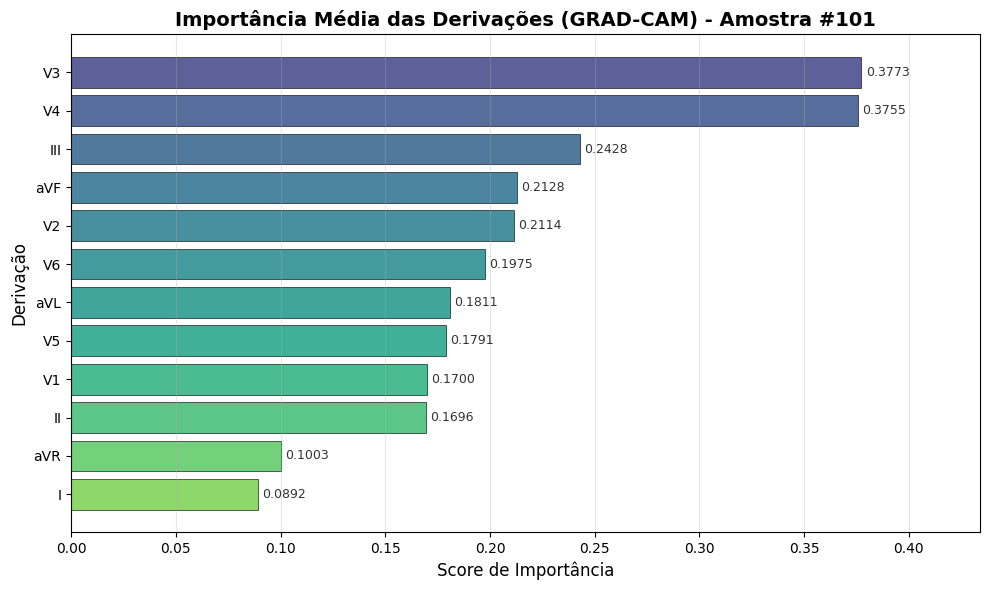

,Lead,Importance
8,V3,0.377329
9,V4,0.375539
2,III,0.242835
5,aVF,0.212799
7,V2,0.211443
11,V6,0.197467
4,aVL,0.181061
10,V5,0.179089
6,V1,0.169962
1,II,0.169554


In [ ]:
plot_lead_importance_ranking(heatmap, i, lead_names)

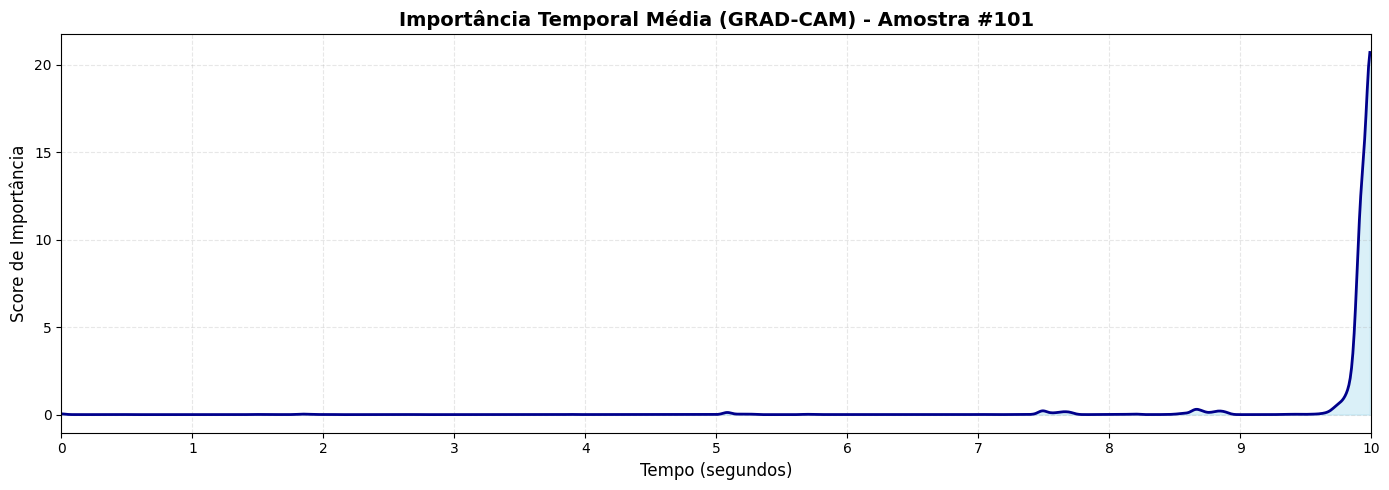

In [ ]:
plot_temporal_importance(heatmap, i)

## modelo 001

In [ ]:
model001 = load_model("..\models\model_0.001_32.keras")

### saliency maps

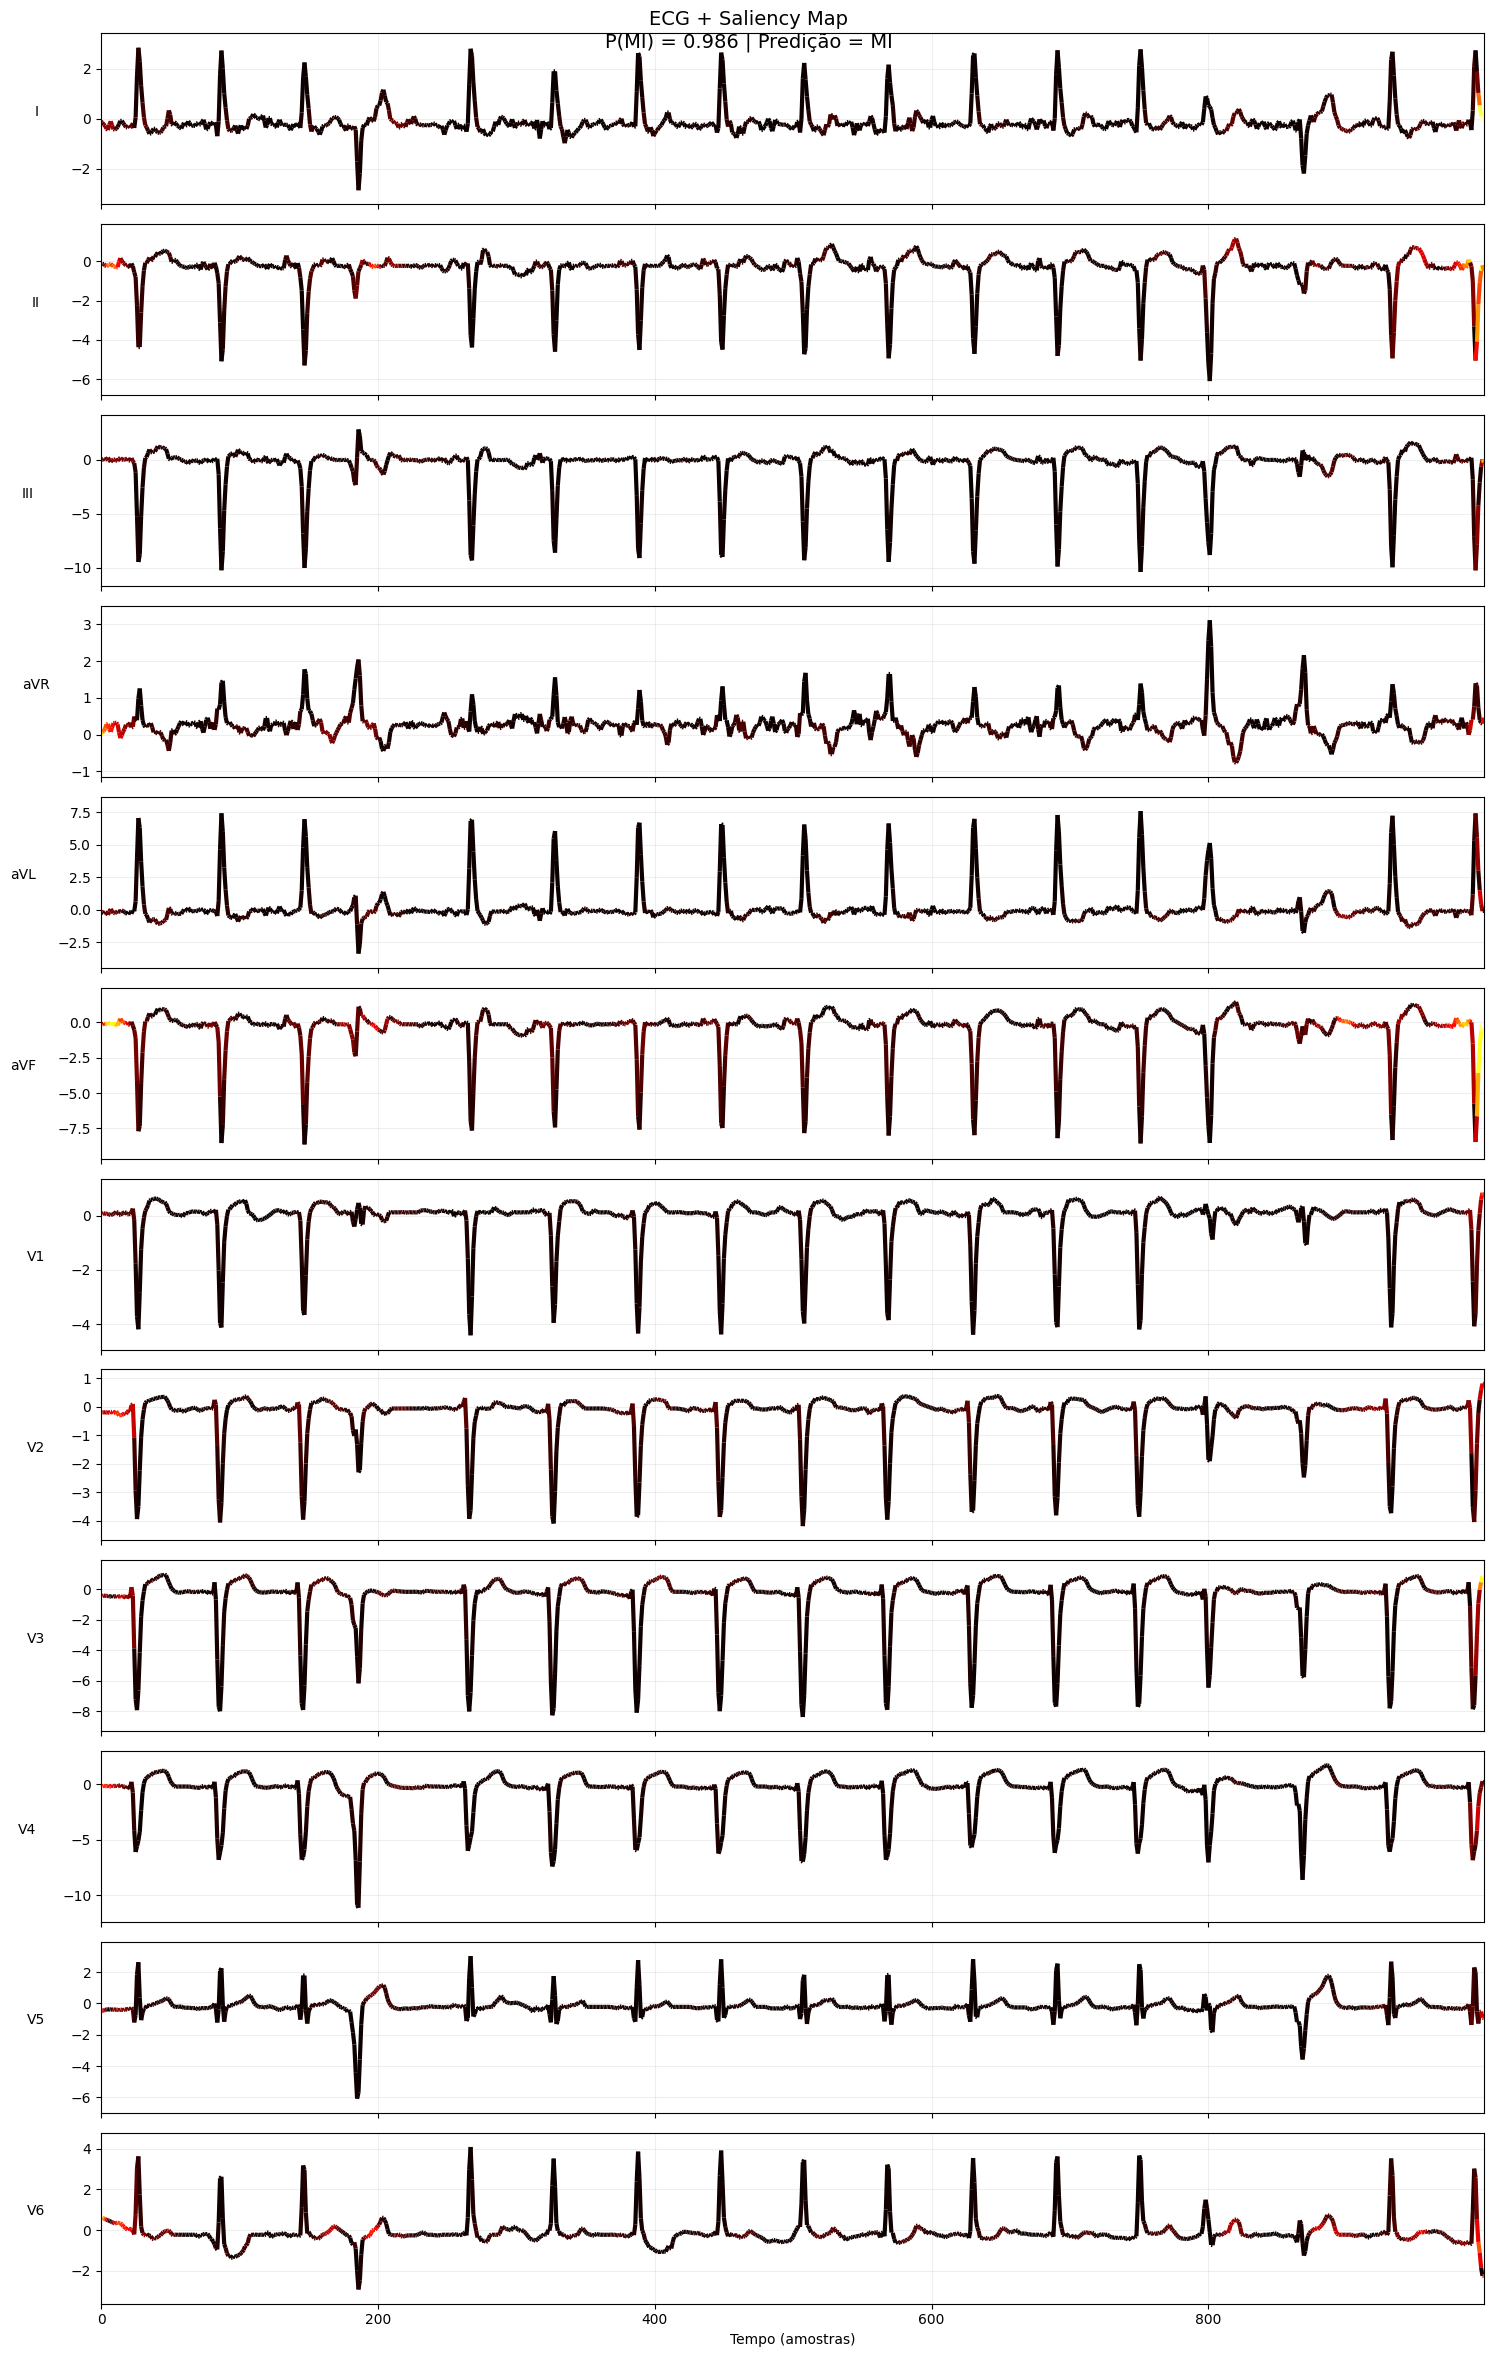

ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "c:\Users\Larissa\miniconda3\envs\tf210\lib\site-packages\keras\backend.py", line 5129, in <genexpr>
    output_ta_t = tuple(  File "c:\Users\Larissa\miniconda3\envs\tf210\lib\site-packages\tensorflow\python\util\tf_should_use.py", line 243, in wrapped
    return _add_should_use_warning(fn(*args, **kwargs),


FileNotFoundError: [Errno 2] No such file or directory: '..\\results\\001\\saliency\\MI\\MI_probMI_0.9857110977172852_.png'

In [ ]:
dir_path = "..\\results\\001\\saliency\\MI"
for i in range(len(mi_cases_x)):
    plot_ecg_saliency_continuo(model001, mi_cases_x[i], dir_path=dir_path)
    plot_ecg_saliency(model001, mi_cases_x[i], dir_path=dir_path)

### gradcam

1/1 [==============================] - 0s 277ms/step


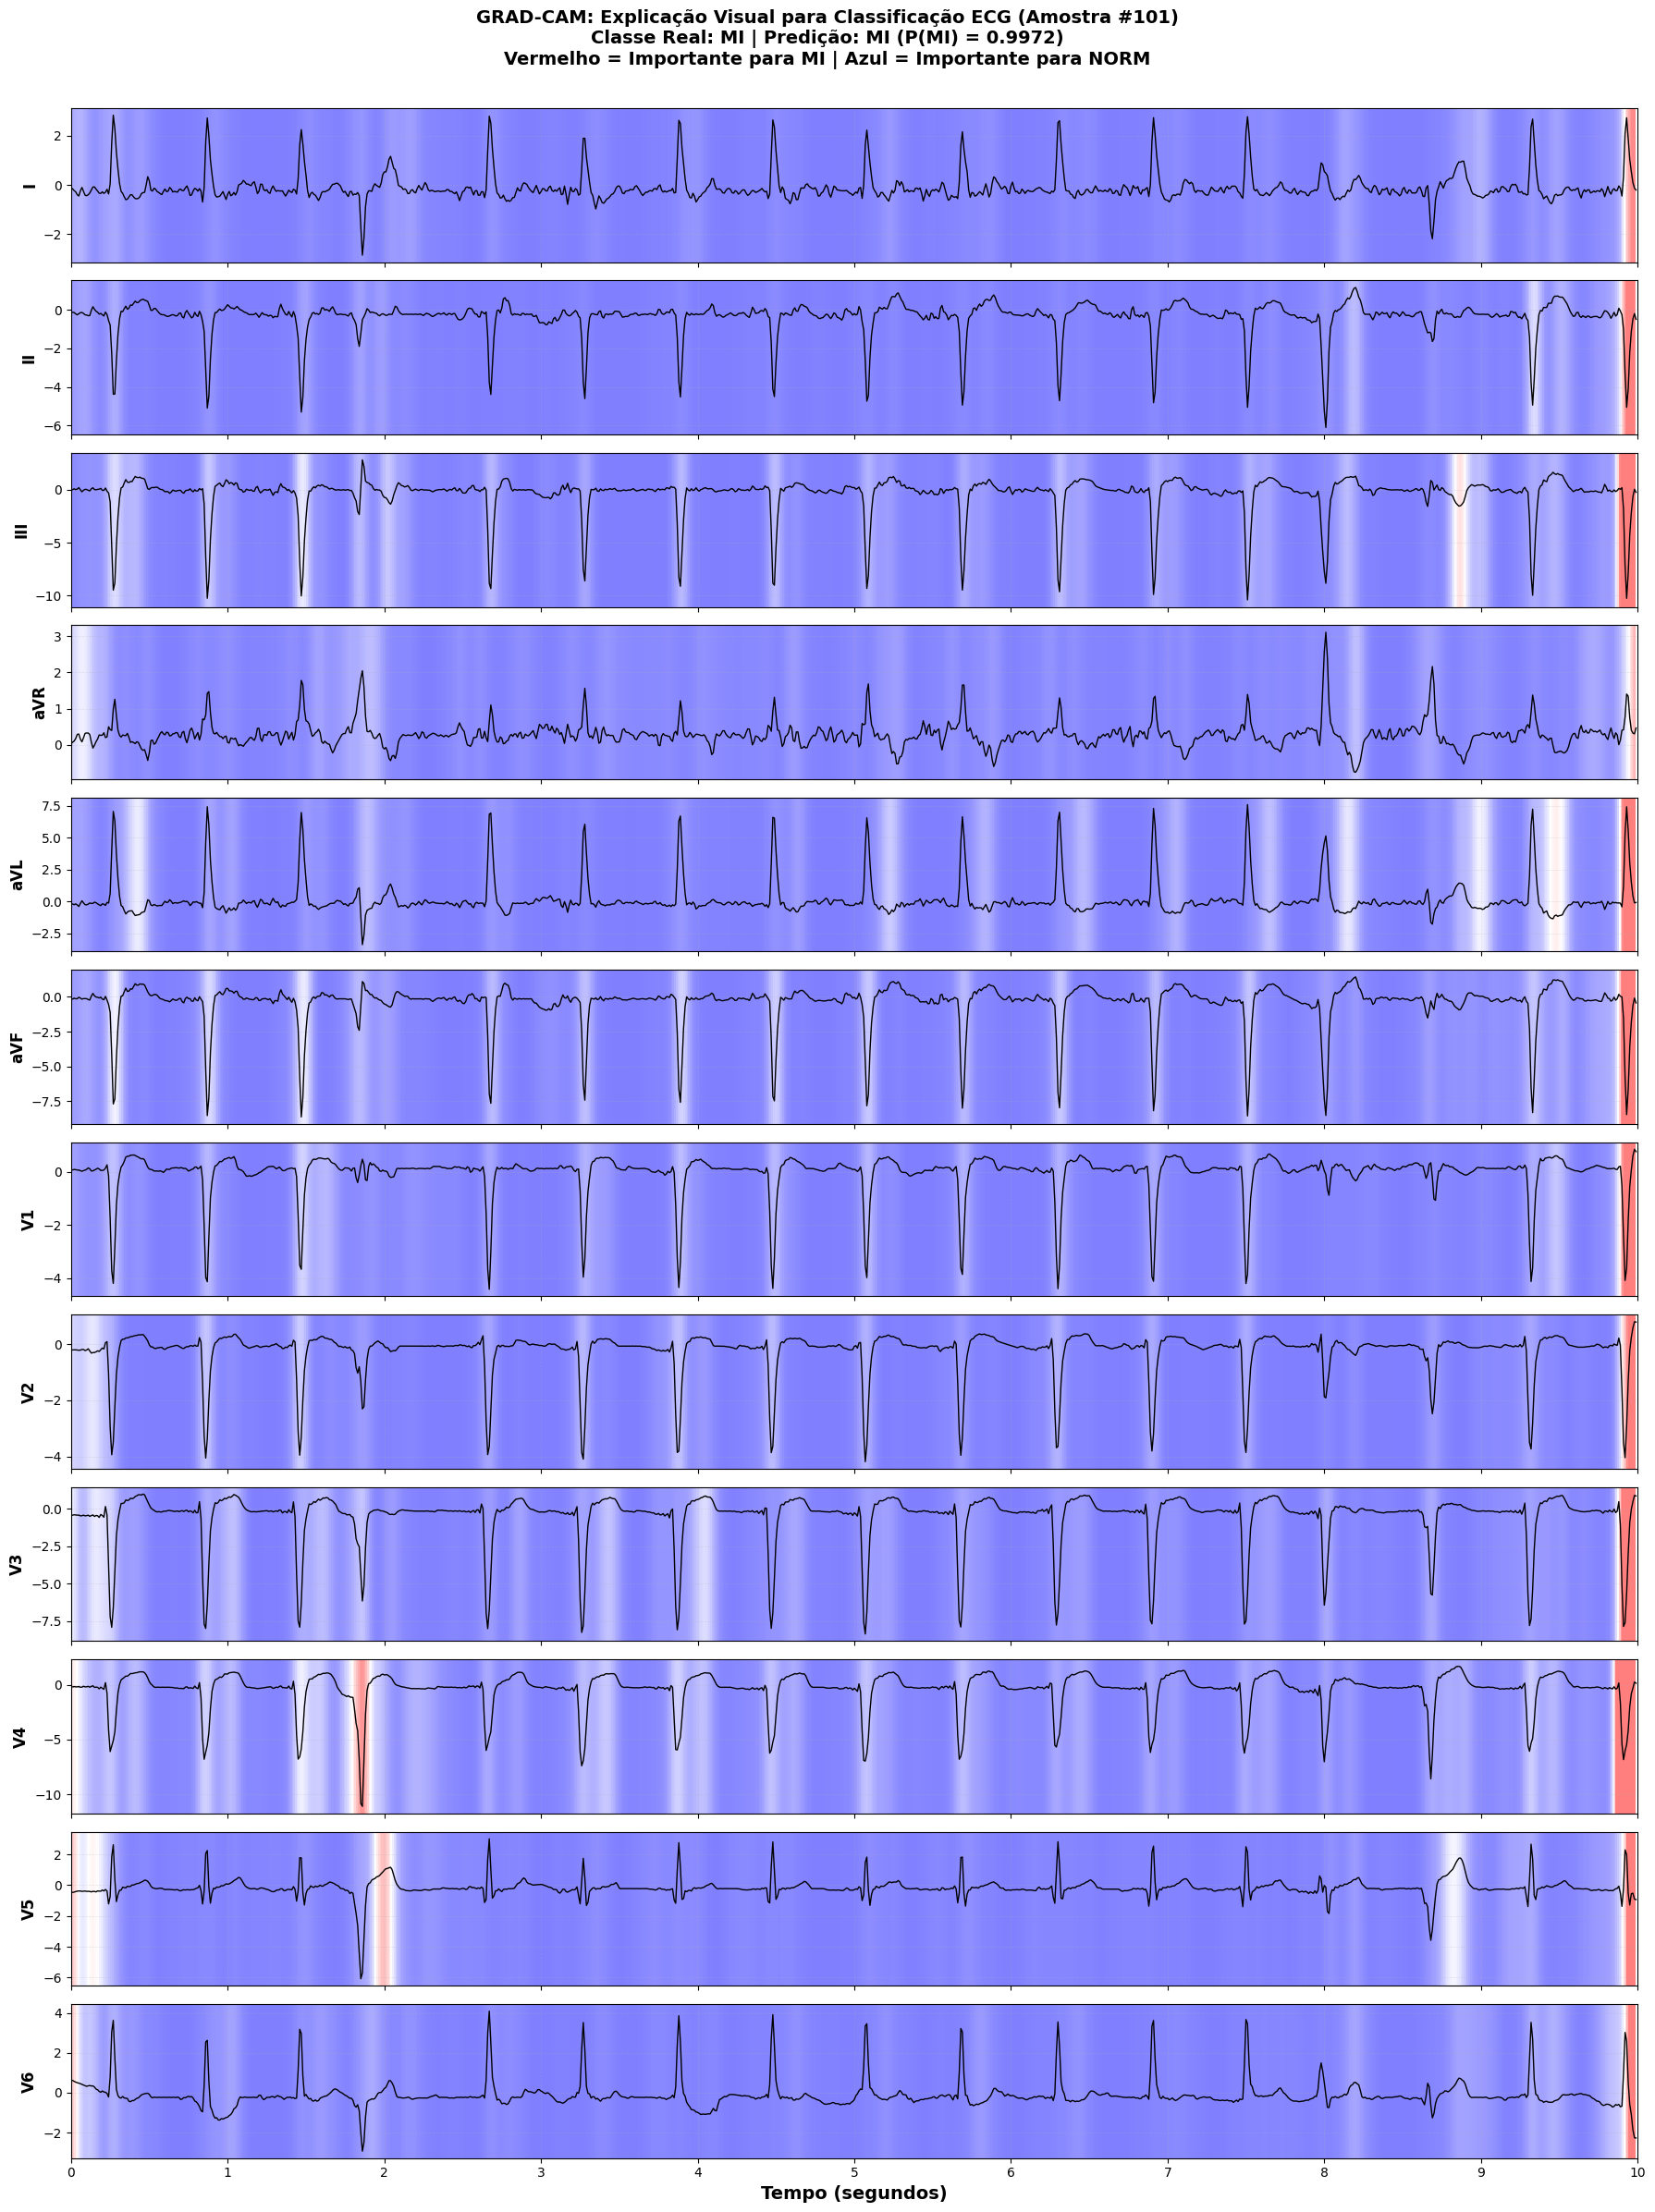

In [ ]:
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
dir_path = "..\\results\\001\\gradcam\\MI"

for i in range(len(mi_cases_x)):
    heatmap, edge_mask = get_gradcam_improved(
        model001,
        np.expand_dims(mi_cases_x[i], axis=0),
        class_idx=1,
        smoothing="gaussian",
        smooth_sigma=3.0,
        edge_handling="trim",
        trim_percent=0.05,
        normalize_method="global"
    )

    plot_ecg_with_gradcam(
        mi_cases_x[i],
        heatmap,
        1,
        float(model01.predict(np.expand_dims(mi_cases_x[i], axis=0))[0,0]),
        i,
        lead_names=lead_names
    )

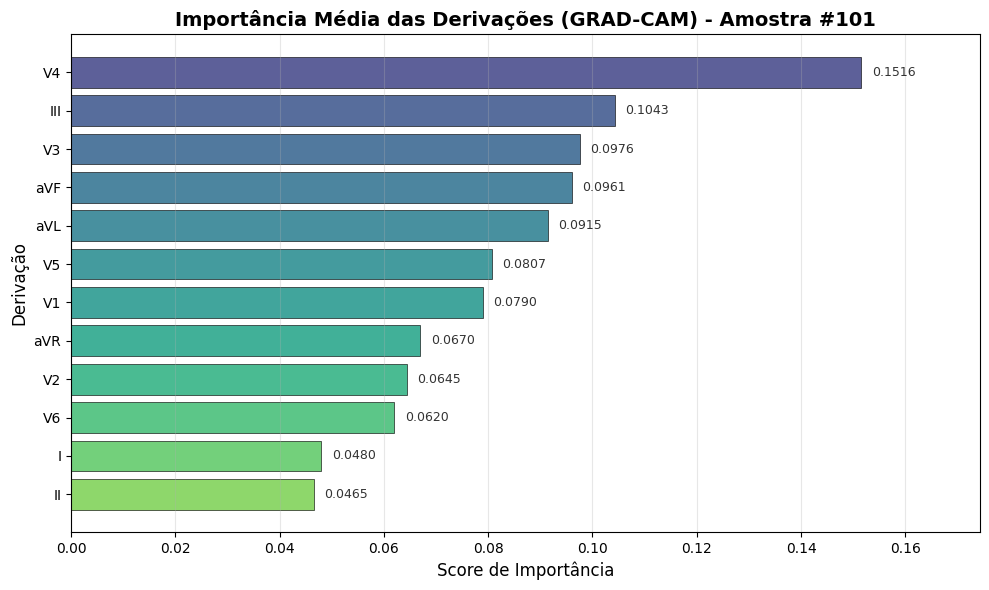

,Lead,Importance
9,V4,0.151579
2,III,0.104271
8,V3,0.097612
5,aVF,0.096088
4,aVL,0.091483
10,V5,0.080667
6,V1,0.079026
3,aVR,0.066997
7,V2,0.064461
11,V6,0.061979


In [ ]:
plot_lead_importance_ranking(heatmap, i, lead_names)

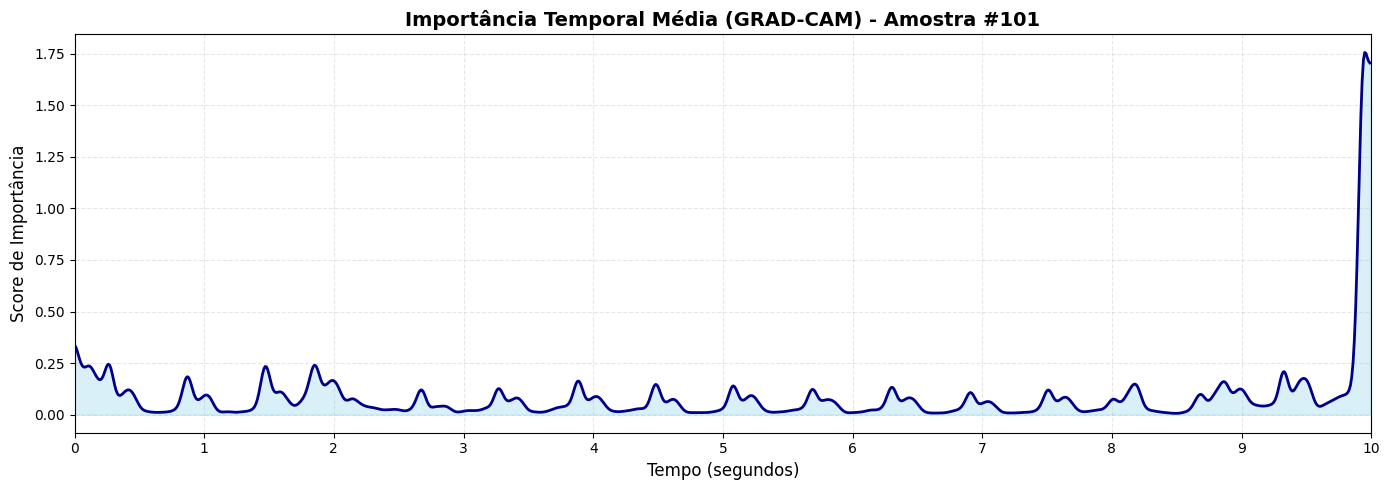

In [ ]:
plot_temporal_importance(heatmap, i)